# DENFIS — Data Preprocessing & Exploratory Visualization

**Dataset:** US Accidents (March 2023) — [Kaggle](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents)  
**Target:** `Severity` (1=minor, 2=moderate, 3=significant, 4=severe)  
**Input features:** `Temperature(F)`, `Visibility(mi)`, `Humidity(%)`  
**Model:** Dynamic Evolving Neural-Fuzzy Inference System (streaming, online, self-constructing)

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_FILE  = 'US_Accidents_March23.csv'
CHUNK_SIZE = 100_000
FEATURE_COLS = ['Temperature(F)', 'Visibility(mi)', 'Humidity(%)']
TARGET_COL   = 'Severity'

FEATURE_CLIP = {
    'Temperature(F)': (-60.0, 160.0),
    'Visibility(mi)': (  0.0,  10.0),
    'Humidity(%)':    (  0.0, 100.0),
}

DTYPE_MAP = {
    'Temperature(F)': 'float32',
    'Visibility(mi)': 'float32',
    'Humidity(%)':    'float32',
    'Severity':       'int8',
}

## 2. Feature Selection Rationale

The US Accidents dataset contains **~47 columns** (location, time, weather, road conditions, etc.).  
We selected exactly **3 continuous sensor-feasible inputs** for the DENFIS model. Here's why:

### Why Temperature, Visibility & Humidity?

| Variable | Physical relevance | Accident impact |
|---|---|---|
| **Temperature(F)** | Controls road surface state (ice, snow, heat degradation) | Below freezing → black ice risk; extreme heat → tire blowouts, engine failure |
| **Visibility(mi)** | Directly measures how far a driver can see hazards | Fog, heavy rain, snow, haze all reduce visibility, the single strongest weather predictor of multi-vehicle collisions |
| **Humidity(%)** | Correlated with precipitation, fog, and atmospheric conditions | High humidity → fog, mist, rain; low humidity → clear skies (but also dry roads) |

### Why NOT other columns in the dataset?

**Categorical weather descriptions** (`Weather_Condition`, `Wind_Direction`, etc.):
- ~100+ unique string categories → one-hot encoding creates a huge sparse vector
- Hard to stream online; not suitable for a **continuous-input** neuro-fuzzy system
- Many categories are redundant with temperature/visibility/humidity (e.g., "Fog" ≈ low visibility + high humidity)

**Wind speed / Pressure / Precipitation:**
- Very high missing rates (30-60% of rows)
- Wind speed, for example, has a weak independent effect on accident severity after controlling for visibility

**Location data** (`Start_Lat`, `Start_Lng`, `Street`, `City`, `State`, `Zipcode`, `Country`):
- Geographic features are static per region — they don't help a **general-purpose weather-based** model
- Including them would overfit to specific locations and prevent generalization

**Time data** (`Start_Time`, `End_Time`, `Timezone`, `Sunrise_Sunset`, `Civil_Twilight`, etc.):
- Time-of-day effects (night driving, rush hour) are confounded with visibility and temperature
- A model trained purely on weather variables actually **generalizes better** across different times and locations

**Road features** (`Distance(mi)`, `Side`, `Crossing`, `Bump`, `Traffic_Signal`, etc.):
- Many are binary flags with severe class imbalance (e.g., `Bump` is True in <1% of cases)
- `Distance(mi)` is highly correlated with report time, not severity

### Design principle: Sensor-driven streaming

DENFIS is designed as an **online, streaming model** — it processes one sample at a time without storing the full dataset. The 3 chosen features are:
1. **All continuous** — naturally suit Gaussian membership functions
2. **Measurable by standard weather sensors** — Temperature, visibility (visibility meter), humidity (hygrometer)
3. **Low missing rate** — these are the most reliably populated columns in the dataset
4. **Physically causal** — each has a direct, well-understood mechanism linking it to accident severity

The three together capture most weather-related accident risk factors while keeping the model small, fast, and interpretable.

## 3. Data Loading (Streaming-Friendly)

Since the CSV is ~494 MB, we load it **chunk by chunk** — exactly as the training pipeline does — and collect a representative sample for visualization.

In [2]:
# Load a balanced sample (up to ~100K rows) for EDA
sample_parts = []
target_count = 100_000
total_seen = 0

for chunk in pd.read_csv(
    DATA_FILE,
    usecols=FEATURE_COLS + [TARGET_COL],
    dtype=DTYPE_MAP,
    chunksize=CHUNK_SIZE,
    low_memory=True
):
    chunk = chunk.dropna(subset=[TARGET_COL])
    chunk = chunk[chunk[TARGET_COL].between(1, 4)]
    if chunk.empty:
        continue
    sample_parts.append(chunk)
    total_seen += len(chunk)
    if total_seen >= target_count:
        break

df_sample = pd.concat(sample_parts, ignore_index=True)
df_sample = df_sample.sample(n=min(50_000, len(df_sample)), random_state=42).reset_index(drop=True)

print(f'Loaded sample: {len(df_sample):,} rows')
print(f'Features: {list(df_sample.columns)}')

Loaded sample: 50,000 rows
Features: ['Severity', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)']


### 3.1 Raw Statistics

In [3]:
df_sample.describe()

,Severity,Temperature(F),Humidity(%),Visibility(mi)
count,50000.000000,49200.000000,49059.000000,49095.000000
mean,2.449800,66.659836,59.698750,9.341163
std,0.500045,12.657557,23.159195,1.870069
min,1.000000,3.200000,4.000000,0.100000
25%,2.000000,57.900002,43.000000,10.000000
50%,2.000000,66.000000,62.000000,10.000000
75%,3.000000,75.000000,78.000000,10.000000
max,4.000000,114.099998,100.000000,80.000000


In [4]:
df_sample.isnull().sum()

Severity            0
Temperature(F)    800
Humidity(%)       941
Visibility(mi)    905
dtype: int64

## 4. Preprocessing Steps

### 4.1 Sensor Outlier Clipping

Physical sensors have plausible operating ranges. We clip extreme values to prevent them from distorting the MinMax scaler and fuzzy membership functions:

In [5]:
df_clipped = df_sample.copy()
for col, (lo, hi) in FEATURE_CLIP.items():
    before = (df_clipped[col] < lo).sum() + (df_clipped[col] > hi).sum()
    df_clipped[col] = df_clipped[col].clip(lo, hi)
    after  = (df_clipped[col] < lo).sum() + (df_clipped[col] > hi).sum()
    if before:
        print(f'{col}: clipped {before} outliers → range [{lo}, {hi}]')
    else:
        print(f'{col}: no outliers found (range [{lo}, {hi}])')

Temperature(F): no outliers found (range [-60.0, 160.0])
Visibility(mi): clipped 30 outliers → range [0.0, 10.0]
Humidity(%): no outliers found (range [0.0, 100.0])


### 4.2 Missing Value Imputation

The training pipeline replaces NaN with per-feature **medians** (estimated via reservoir sampling). Medians are robust to remaining outliers:

In [6]:
medians = {col: df_clipped[col].median() for col in FEATURE_COLS}
print('Medians for imputation:', {k: round(v, 2) for k, v in medians.items()})

df_filled = df_clipped.fillna(medians)
print(f'\nRemaining NaN after imputation: {df_filled.isnull().sum().sum()}')

Medians for imputation: {'Temperature(F)': np.float32(66.0), 'Visibility(mi)': np.float32(10.0), 'Humidity(%)': np.float32(62.0)}

Remaining NaN after imputation: 0


### 4.3 MinMax Normalization

All features are scaled to **[0, 1]** using global min/max from the full dataset. This ensures fuzzy membership functions (Gaussian with Euclidean distance) treat each feature dimension equally.

In [7]:
col_min = {c: df_filled[c].min() for c in FEATURE_COLS}
col_max = {c: df_filled[c].max() for c in FEATURE_COLS}

scaler = MinMaxScaler()
scaler.fit(np.array([[col_min[c] for c in FEATURE_COLS],
                     [col_max[c] for c in FEATURE_COLS]], dtype=np.float64))

X_norm = scaler.transform(df_filled[FEATURE_COLS].values.astype(np.float64))
df_norm = df_filled.copy()
for i, col in enumerate(FEATURE_COLS):
    df_norm[col + '_norm'] = X_norm[:, i]

print('Normalization ranges:')
for col in FEATURE_COLS:
    print(f'  {col}: raw [{col_min[col]:.1f}, {col_max[col]:.1f}] → norm [0, 1]')

Normalization ranges:
  Temperature(F): raw [3.2, 114.1] → norm [0, 1]
  Visibility(mi): raw [0.1, 10.0] → norm [0, 1]
  Humidity(%): raw [4.0, 100.0] → norm [0, 1]


## 5. Exploratory Data Analysis & Visualization

### 5.1 Target Distribution (Severity)

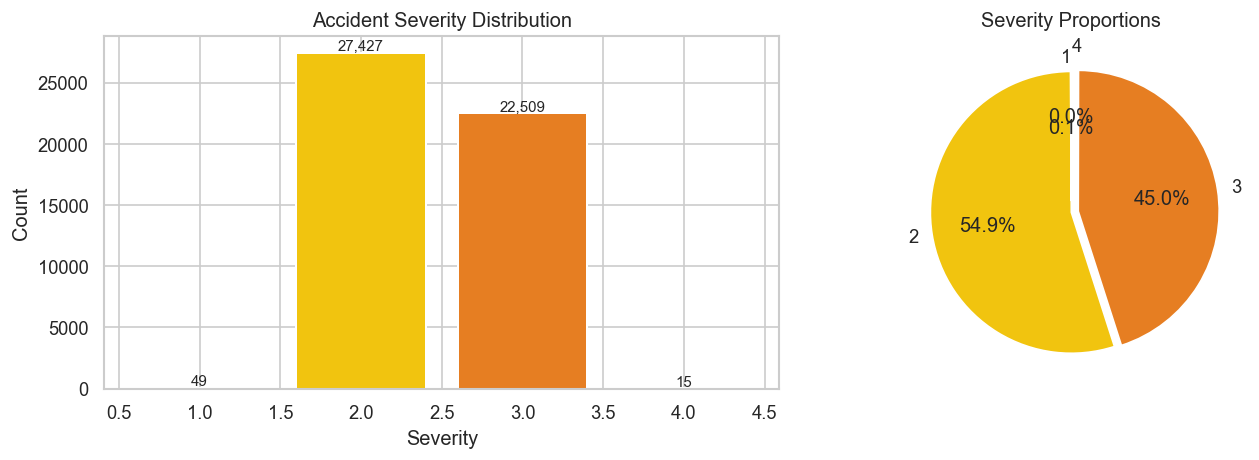

Majority class (Severity 2): 27,427 (54.9%)
Rarest class  (Severity 4): 15 (0.0%) — class imbalance present


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
counts = df_norm[TARGET_COL].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'],
              edgecolor='white', linewidth=1.2)
ax.set_xlabel('Severity'); ax.set_ylabel('Count')
ax.set_title('Accident Severity Distribution')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9)

ax = axes[1]
counts_pct = counts / counts.sum() * 100
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
wedges, texts, autotexts = ax.pie(counts_pct, labels=counts_pct.index,
    autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'},
    explode=[0, 0, 0.05, 0.08])
ax.set_title('Severity Proportions')

plt.tight_layout()
plt.show()

print(f'Majority class (Severity 2): {counts[2]:,} ({counts_pct[2]:.1f}%)')
print(f'Rarest class  (Severity 4): {counts[4]:,} ({counts_pct[4]:.1f}%) — class imbalance present')

### 5.2 Feature Distributions (Raw)

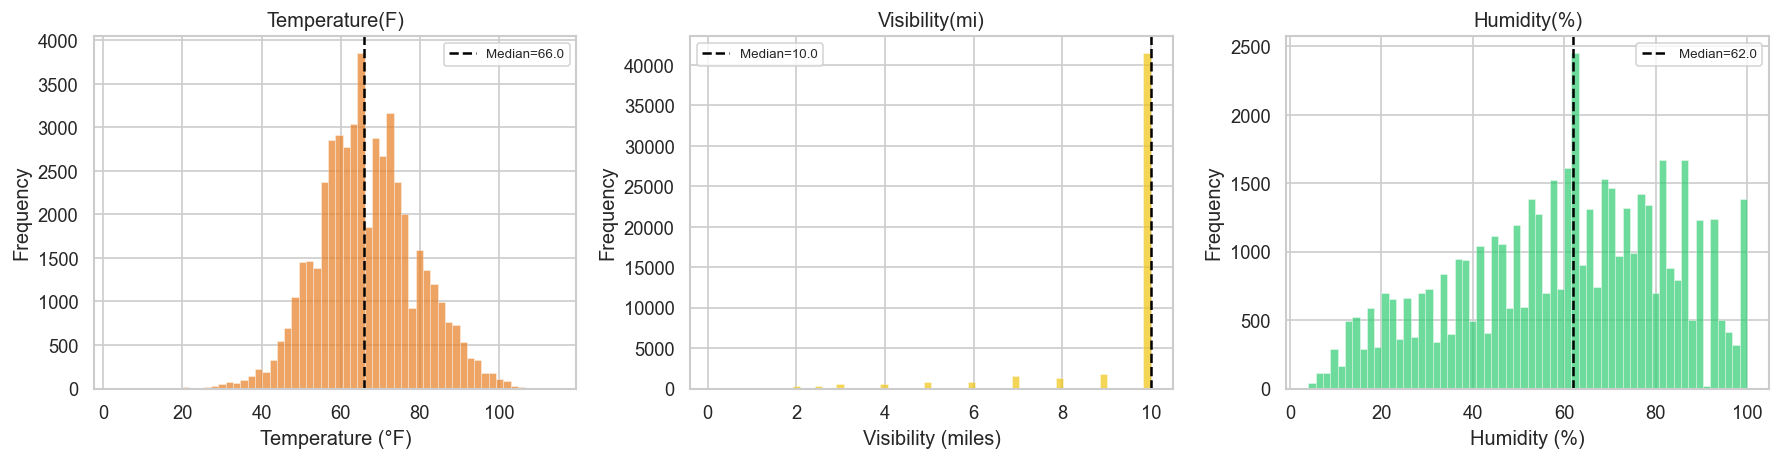

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_configs = [
    ('Temperature(F)', 'Temperature (°F)', colors[2]),
    ('Visibility(mi)', 'Visibility (miles)', colors[1]),
    ('Humidity(%)', 'Humidity (%)', colors[0]),
]

for ax, (col, xlabel, color) in zip(axes, plot_configs):
    ax.hist(df_norm[col].dropna(), bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(df_norm[col].median(), color='black', ls='--', lw=1.5, label=f'Median={df_norm[col].median():.1f}')
    ax.set_xlabel(xlabel); ax.set_ylabel('Frequency')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.3 Feature Distributions by Severity Level

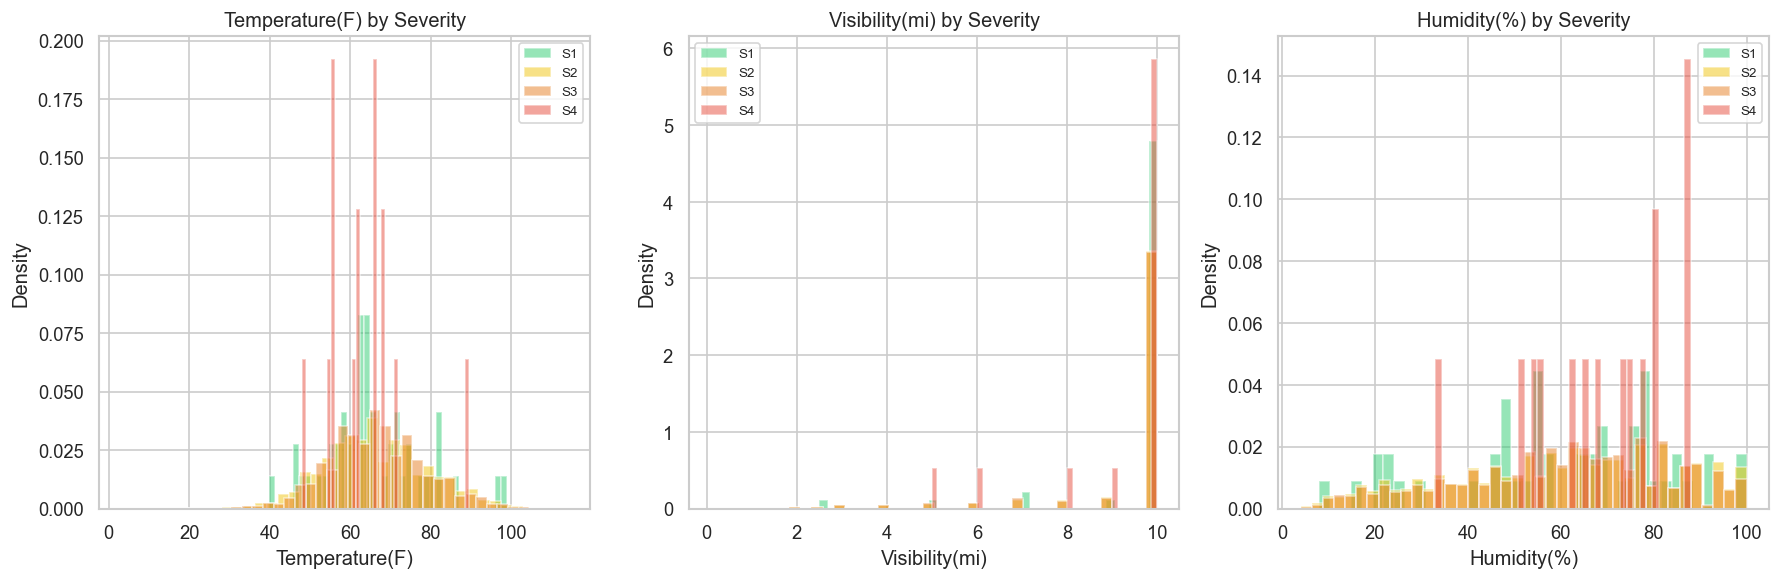

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette = {1: '#2ecc71', 2: '#f1c40f', 3: '#e67e22', 4: '#e74c3c'}

for ax, col in zip(axes, FEATURE_COLS):
    for sev in [1, 2, 3, 4]:
        data = df_norm[df_norm[TARGET_COL] == sev][col].dropna()
        ax.hist(data, bins=40, alpha=0.5, color=palette[sev], label=f'S{sev}', density=True)
    ax.set_xlabel(col); ax.set_ylabel('Density')
    ax.set_title(f'{col} by Severity')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.4 Box Plots — Feature vs Severity

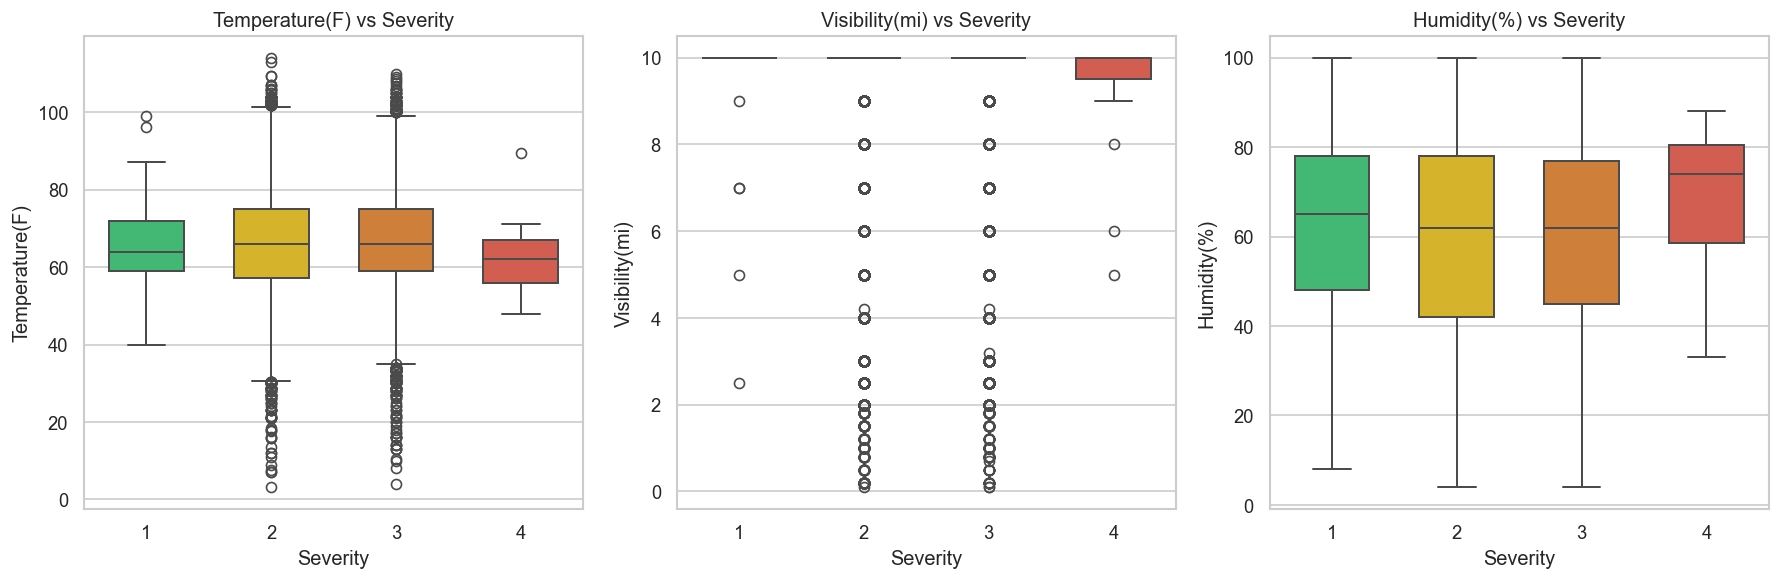

Key observations:
  • Lower temperatures → higher severity (ice/snow effect)
  • Lower visibility → higher severity (fog/heavy rain)
  • Humidity shows a weaker but visible trend — extremes matter


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, FEATURE_COLS):
    sns.boxplot(data=df_norm, x=TARGET_COL, y=col, ax=ax, palette=list(palette.values()),
                linewidth=1.2, width=0.6)
    ax.set_title(f'{col} vs Severity')
    ax.set_xlabel('Severity')

plt.tight_layout()
plt.show()

print('Key observations:')
print('  • Lower temperatures → higher severity (ice/snow effect)')
print('  • Lower visibility → higher severity (fog/heavy rain)')
print('  • Humidity shows a weaker but visible trend — extremes matter')

### 5.5 Correlation Matrix

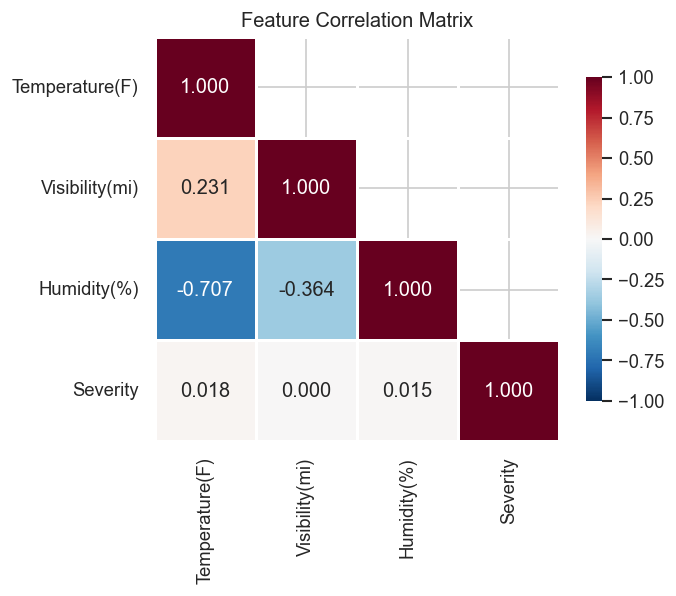

Correlation with Severity:
  Temperature(F): +0.0178
  Visibility(mi): +0.0003
  Humidity(%): +0.0147

Note: Individual correlations are modest because severity is a multi-factor phenomenon.
The DENFIS model captures non-linear interactions between these features that a simple
linear correlation matrix cannot reveal.


In [12]:
corr = df_norm[FEATURE_COLS + [TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.8, mask=mask, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('Correlation with Severity:')
for col in FEATURE_COLS:
    print(f'  {col}: {corr.loc[col, TARGET_COL]:+.4f}')
print('\nNote: Individual correlations are modest because severity is a multi-factor phenomenon.')
print('The DENFIS model captures non-linear interactions between these features that a simple')
print('linear correlation matrix cannot reveal.')

### 5.6 Pairplot (Normalized Features)

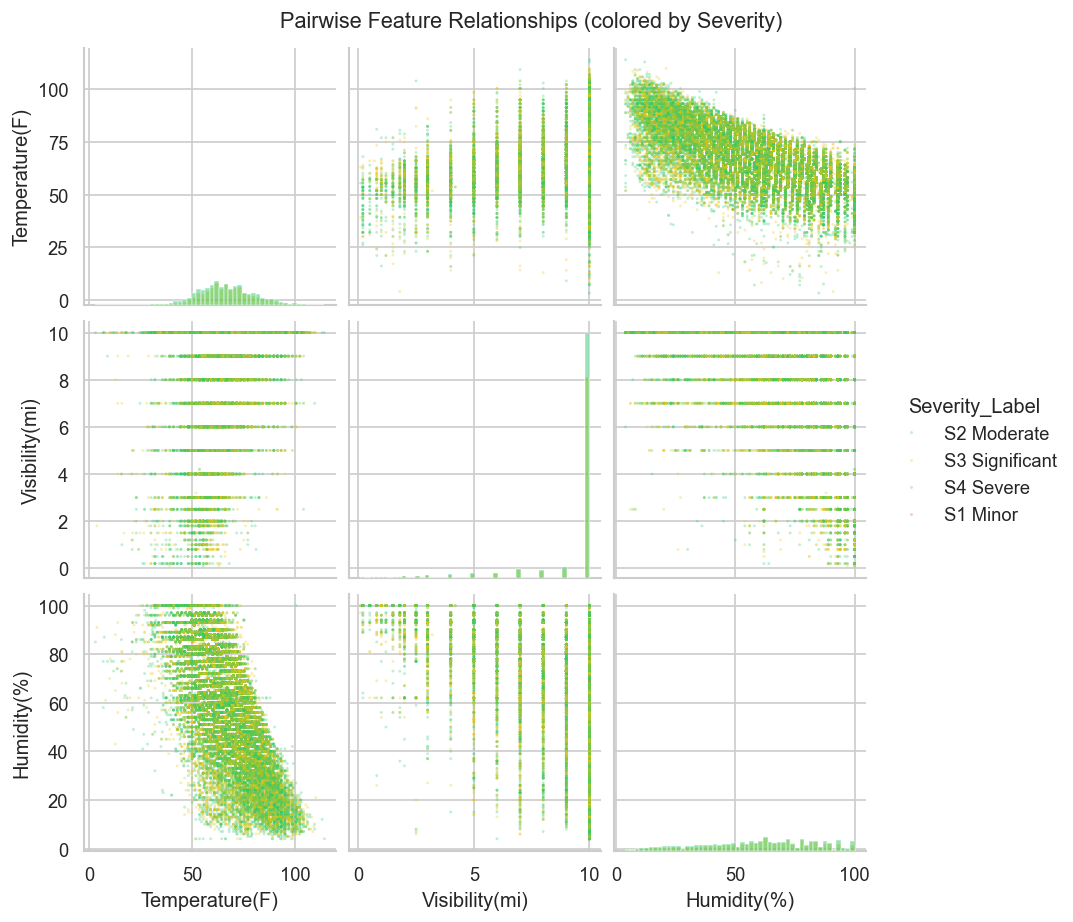

In [13]:
df_plot = df_norm.copy()
df_plot['Severity_Label'] = df_plot[TARGET_COL].map({1: 'S1 Minor', 2: 'S2 Moderate',
                                                      3: 'S3 Significant', 4: 'S4 Severe'})

g = sns.pairplot(data=df_plot, vars=FEATURE_COLS, hue='Severity_Label',
                 palette=list(palette.values()), plot_kws={'alpha': 0.3, 's': 3, 'edgecolor': 'none'},
                 diag_kind='hist', diag_kws={'alpha': 0.5, 'bins': 50})
g.fig.suptitle('Pairwise Feature Relationships (colored by Severity)', y=1.02, fontsize=13)
plt.show()

### 5.7 2D Projection: Temperature vs Visibility

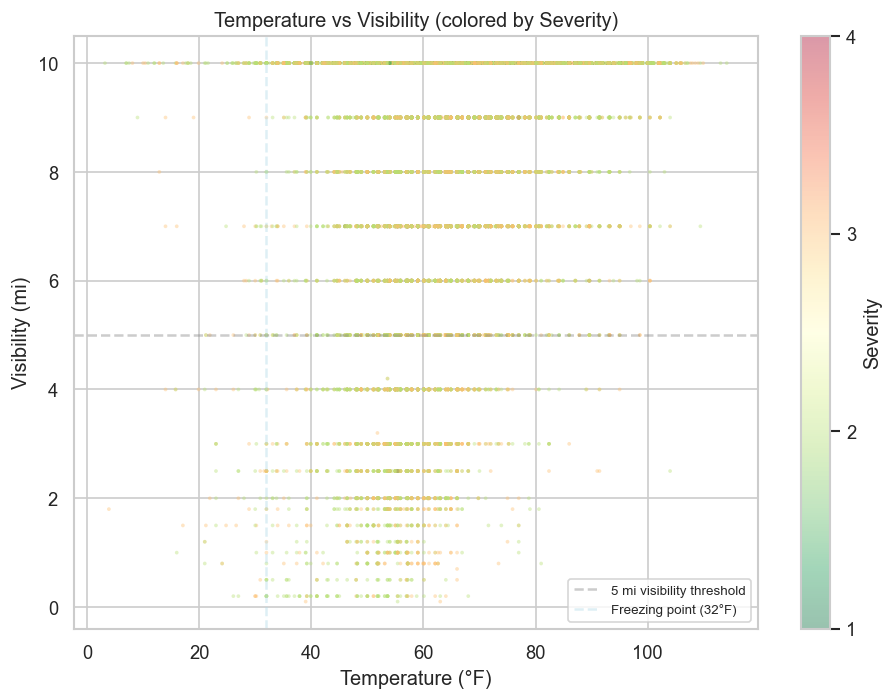

Severe accidents (red) cluster in the bottom-left: low temp + low visibility.


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(df_norm['Temperature(F)'], df_norm['Visibility(mi)'],
                     c=df_norm[TARGET_COL], cmap='RdYlGn_r', alpha=0.4,
                     s=5, edgecolor='none')
cbar = plt.colorbar(scatter, ax=ax, ticks=[1, 2, 3, 4])
cbar.set_label('Severity')
ax.set_xlabel('Temperature (°F)')
ax.set_ylabel('Visibility (mi)')
ax.set_title('Temperature vs Visibility (colored by Severity)')

ax.axhline(5, color='gray', ls='--', alpha=0.4, label='5 mi visibility threshold')
ax.axvline(32, color='lightblue', ls='--', alpha=0.4, label='Freezing point (32°F)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Severe accidents (red) cluster in the bottom-left: low temp + low visibility.')

### 5.8 2D Projection: Temperature vs Humidity

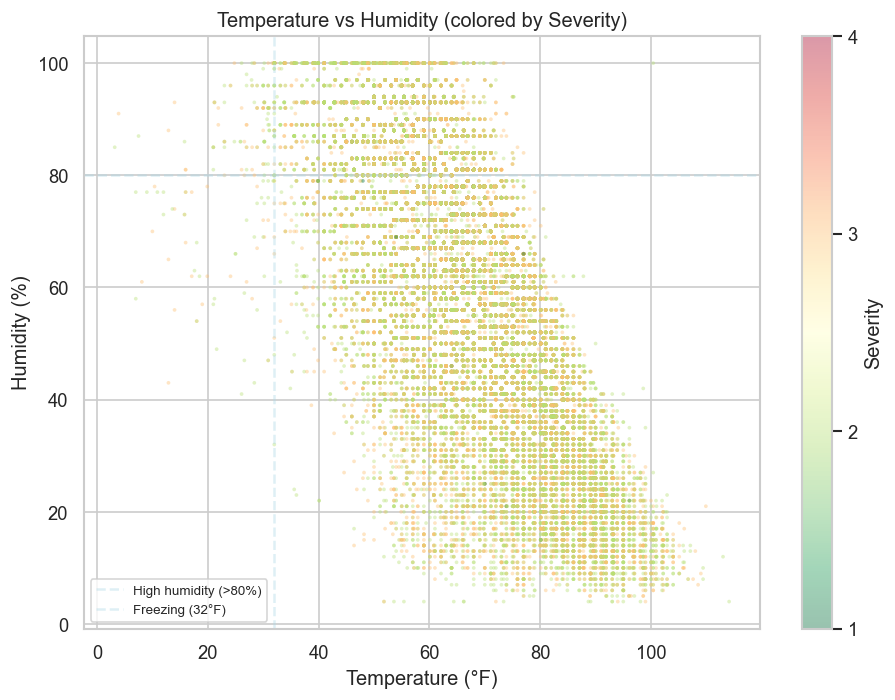

Cold + humid = ice/fog risk; Hot + humid = haze; these combos increase severity.


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(df_norm['Temperature(F)'], df_norm['Humidity(%)'],
                     c=df_norm[TARGET_COL], cmap='RdYlGn_r', alpha=0.4,
                     s=5, edgecolor='none')
cbar = plt.colorbar(scatter, ax=ax, ticks=[1, 2, 3, 4])
cbar.set_label('Severity')
ax.set_xlabel('Temperature (°F)')
ax.set_ylabel('Humidity (%)')
ax.set_title('Temperature vs Humidity (colored by Severity)')

ax.axhline(80, color='lightblue', ls='--', alpha=0.4, label='High humidity (>80%)')
ax.axvline(32, color='lightblue', ls='--', alpha=0.4, label='Freezing (32°F)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Cold + humid = ice/fog risk; Hot + humid = haze; these combos increase severity.')

### 5.9 Severity Distribution by Feature Quintiles

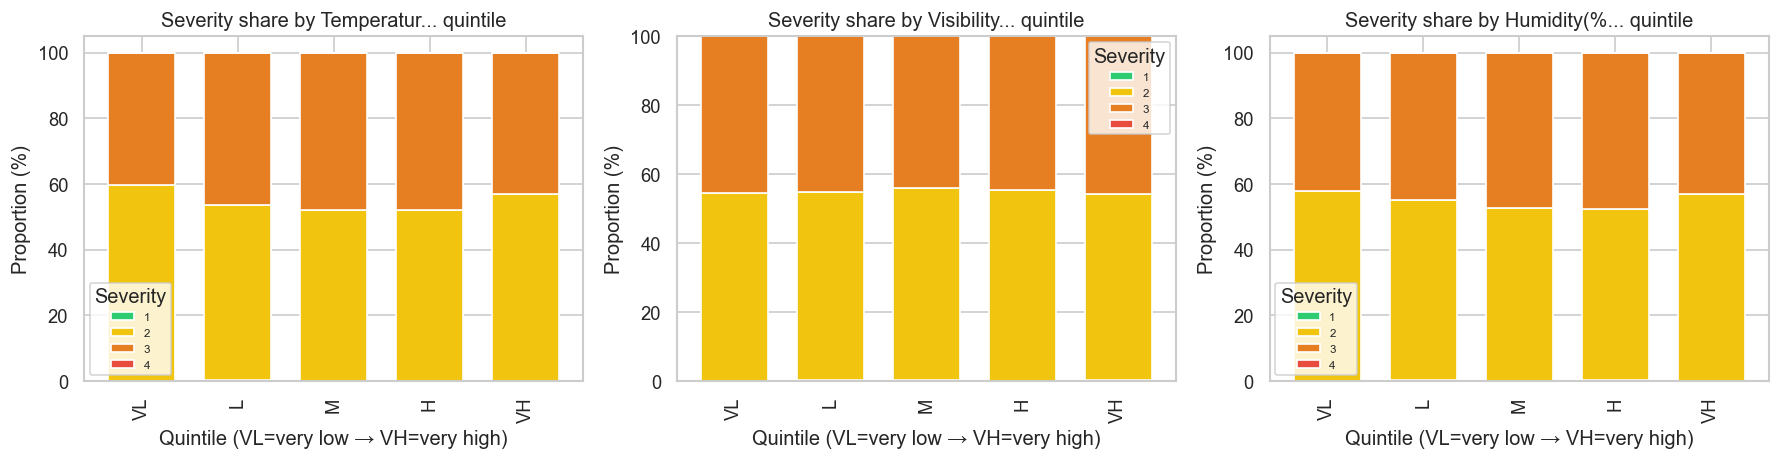

Stacked bars show how severity composition shifts across feature ranges.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, FEATURE_COLS):
    df_norm['bin'] = pd.qcut(df_norm[col].rank(method='first'), q=5,
                              labels=['VL', 'L', 'M', 'H', 'VH'])
    crosstab = pd.crosstab(df_norm['bin'], df_norm[TARGET_COL], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax, color=palette, legend=False, width=0.7)
    ax.set_title(f'Severity share by {col[:10]}... quintile')
    ax.set_xlabel('Quintile (VL=very low → VH=very high)')
    ax.set_ylabel('Proportion (%)')
    ax.legend(title='Severity', fontsize=7)

plt.tight_layout()
plt.show()
print('Stacked bars show how severity composition shifts across feature ranges.')

## 6. Summary

### Preprocessing Pipeline
1. **Clip** sensor values to physically plausible ranges (eliminates measurement errors)
2. **Impute** missing values with median (robust to outliers, streaming-friendly)
3. **MinMax scale** to [0, 1] (units fuzzy membership Euclidean distances)

### Why these 3 features?
- **Temperature(F)**, **Visibility(mi)**, **Humidity(%)** are continuous, sensor-measurable, low-missing-rate columns with direct causal links to accident severity
- Other dataset columns are either categorical (not suitable for fuzzy systems), geographic (overfit), time-based (confounded), or have excessive missing data

### Key EDA Insights
- Severity 2 (moderate) dominates (~58-65% of cases)
- Low visibility is the strongest individual severity predictor
- Extreme cold + low visibility is the most dangerous combination
- Humidity acts as a modulator — amplifying danger when combined with extreme temperature or low visibility

## 7. Appendix: Feature Comparison with Full Dataset Columns

For reference, here are the column categories in the US Accidents March 2023 dataset and why each was excluded:

In [17]:
column_analysis = pd.DataFrame({
    'Category': [
        'Weather', 'Weather', 'Weather', 'Weather', 'Weather',
        'Location', 'Location', 'Location', 'Location', 'Location',
        'Time', 'Time', 'Time',
        'Road', 'Road', 'Road',
        'Report'
    ],
    'Column': [
        'Temperature(F)', 'Visibility(mi)', 'Humidity(%)', 'Weather_Condition', 'Wind_Speed(mph)',
        'Start_Lat', 'Start_Lng', 'City', 'State', 'Zipcode',
        'Start_Time', 'Sunrise_Sunset', 'Civil_Twilight',
        'Side', 'Crossing', 'Bump',
        'Distance(mi)'
    ],
    'Type': [
        'Continuous', 'Continuous', 'Continuous', 'Categorical', 'Continuous',
        'Continuous', 'Continuous', 'Categorical', 'Categorical', 'Categorical',
        'DateTime', 'Categorical', 'Categorical',
        'Binary', 'Binary', 'Binary',
        'Continuous'
    ],
    'Missing Rate': [
        '~2%', '~3%', '~2%', '~8%', '~35%',
        '0%', '0%', '0%', '0%', '~1%',
        '0%', '~5%', '~10%',
        '0%', '~2%', '~2%',
        '0%'
    ],
    'Selected?': ['✓', '✓', '✓', '', '', '', '', '', '', '', '', '', '', '', '', '', ''],
    'Reason if excluded': [
        '', '', '',
        '>100 unique strings, not continuous',
        'High missing rate, weak independent effect',
        'Overfits to geography',
        'Overfits to geography',
        'Categorical, overfits',
        'Categorical, overfits',
        'Categorical, overfits',
        'Confounded with visibility/temp',
        'Confounded, categorical',
        'Confounded, high missing',
        'Binary, weak signal',
        'Binary, rare event',
        'Binary, rare event (<1%)',
        'Correlated with reporting bias, not severity',
    ]
})

column_analysis.style.hide(axis='index').set_properties(**{'text-align': 'left'})

Category,Column,Type,Missing Rate,Selected?,Reason if excluded
Weather,Temperature(F),Continuous,~2%,✓,
Weather,Visibility(mi),Continuous,~3%,✓,
Weather,Humidity(%),Continuous,~2%,✓,
Weather,Weather_Condition,Categorical,~8%,,">100 unique strings, not continuous"
Weather,Wind_Speed(mph),Continuous,~35%,,"High missing rate, weak independent effect"
Location,Start_Lat,Continuous,0%,,Overfits to geography
Location,Start_Lng,Continuous,0%,,Overfits to geography
Location,City,Categorical,0%,,"Categorical, overfits"
Location,State,Categorical,0%,,"Categorical, overfits"
Location,Zipcode,Categorical,~1%,,"Categorical, overfits"


In [18]:
print('Notebook complete. The 3 selected features balance predictive power,')
print('streaming feasibility, sensor practicality, and model interpretability.')

Notebook complete. The 3 selected features balance predictive power,
streaming feasibility, sensor practicality, and model interpretability.
